# Détection de Tweets Suspects — Analyse Exploratoire

Notebook d'exploration et de prétraitement (Partie 1). Le pipeline complet (prétraitement → vectorisation → entraînement → évaluation) est industrialisé avec **DVC** dans `src/` et `dvc.yaml`.

In [ ]:
# Installer les dépendances (inclut pyyaml, requis par src/preprocess.py)
%pip install -q -r ../requirements.txt

## 1. Chargement des données

In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('../data/raw/tweets_suspect.csv')
df.head()

,message,label
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",1
1,is upset that he can't update his Facebook by ...,1
2,@Kenichan I dived many times for the ball. Man...,1
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",1


In [3]:
print('Dimensions :', df.shape)
print('Variables  :', list(df.columns))
df.info()

Dimensions : (60000, 2)
Variables  : ['message', 'label']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   message  60000 non-null  object
 1   label    60000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 937.6+ KB


## 2. Valeurs manquantes et doublons

In [4]:
print('Valeurs manquantes :\n', df.isnull().sum())
print('\nDoublons :', df.duplicated().sum())

Valeurs manquantes :
 message    0
label      0
dtype: int64

Doublons : 293


## 3. Distribution des classes

Le jeu de données est **fortement déséquilibré** : la classe 1 (suspect) représente ~90 % des observations. Cela justifie l'usage de *class weights* / SMOTE et le suivi du F1-score, de l'AUC et du rappel de la classe minoritaire plutôt que de la seule *accuracy*.

In [5]:
df['label'].value_counts(normalize=True).round(3)

label
1    0.898
0    0.102
Name: proportion, dtype: float64

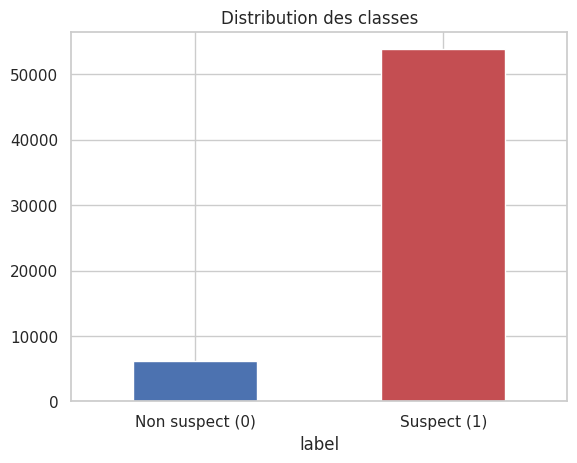

In [6]:
ax = df['label'].value_counts().sort_index().plot(kind='bar', color=['#4C72B0','#C44E52'])
ax.set_xticklabels(['Non suspect (0)','Suspect (1)'], rotation=0)
ax.set_title('Distribution des classes'); plt.show()

## 4. Longueur des tweets

In [7]:
df['len'] = df['message'].str.len()
df['nwords'] = df['message'].str.split().apply(len)
df.groupby('label')[['len','nwords']].describe().T

label                   0             1
len    count  6145.000000  53855.000000
       mean     86.645566     72.277727
       std      35.967343     35.872189
       min       9.000000      6.000000
       25%      57.000000     43.000000
       50%      87.000000     67.000000
       75%     120.000000    100.000000
       max     186.000000    168.000000
nwords count  6145.000000  53855.000000
       mean     15.570871     12.822895
       std       6.813520      6.834765
       min       1.000000      1.000000
       25%      10.000000      7.000000
       50%      16.000000     12.000000
       75%      21.000000     18.000000
       max      34.000000     34.000000

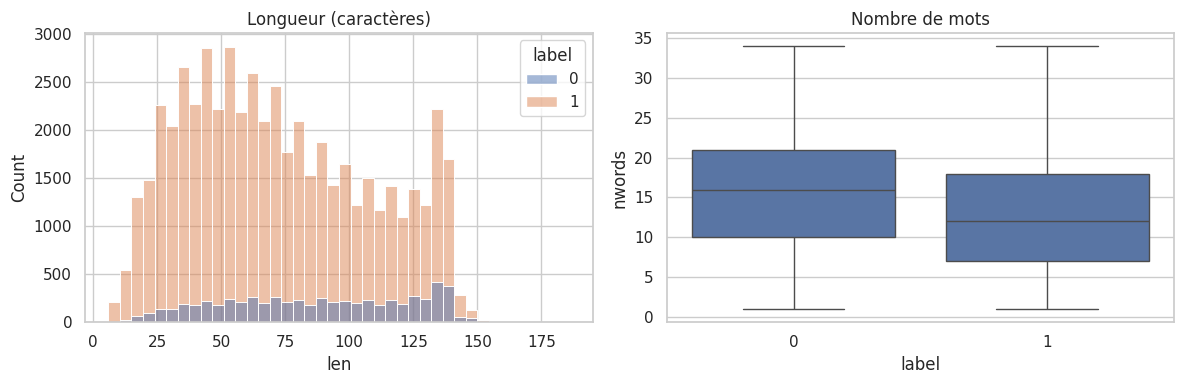

In [8]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.histplot(data=df, x='len', hue='label', bins=40, ax=ax[0])
ax[0].set_title('Longueur (caractères)')
sns.boxplot(data=df, x='label', y='nwords', ax=ax[1])
ax[1].set_title('Nombre de mots'); plt.tight_layout(); plt.show()

## 5. Prétraitement du texte

Opérations (voir `src/preprocess.py`) : minuscules, suppression des URLs, des mentions `@user`, des hashtags, de la ponctuation/chiffres, des *stop words*, puis **stemming** (Porter).

In [9]:
import sys; sys.path.append('../src')
from preprocess import clean_text
ex = df['message'].iloc[0]
print('AVANT :', ex)
print('APRÈS :', clean_text(ex))

AVANT : @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D
APRÈS : awww bummer shoulda got david carr third day


In [10]:
df['clean'] = df['message'].apply(clean_text)
df[['message','clean','label']].head()

,message,clean,label
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww bummer shoulda got david carr third day,1
1,is upset that he can't update his Facebook by ...,upset can updat facebook text might cri result...,1
2,@Kenichan I dived many times for the ball. Man...,dive mani time ball manag save rest go bound,1
3,my whole body feels itchy and like its on fire,whole bodi feel itchi like fire,0
4,"@nationwideclass no, it's not behaving at all....",behav mad can see,1


## 6. Nuages de mots par classe

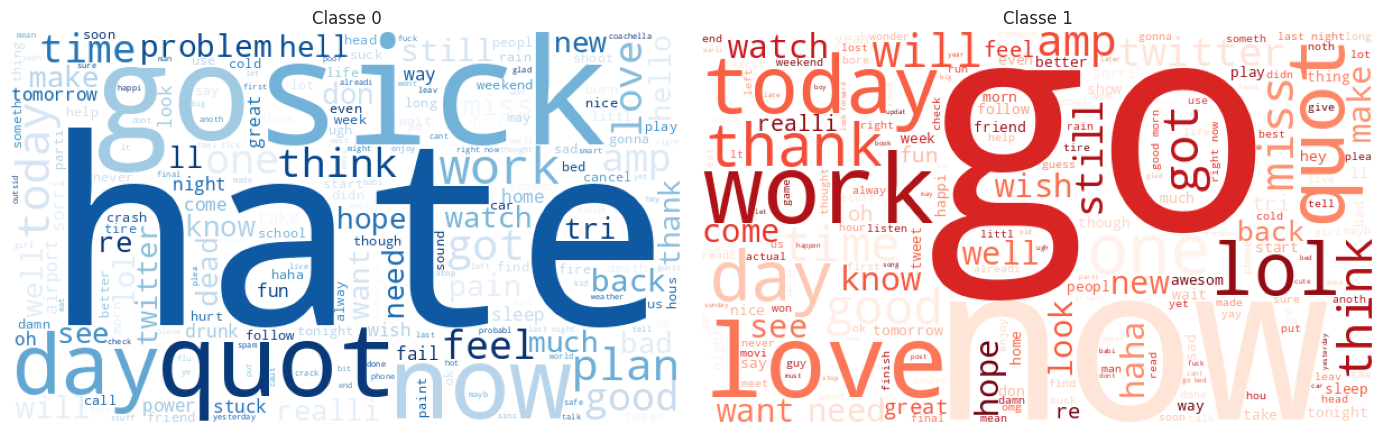

In [11]:
from wordcloud import WordCloud
fig, ax = plt.subplots(1,2, figsize=(14,5))
for i,lab in enumerate([0,1]):
    txt = ' '.join(df[df.label==lab]['clean'])
    wc = WordCloud(width=600, height=350, background_color='white',
                   colormap='Blues' if lab==0 else 'Reds').generate(txt)
    ax[i].imshow(wc); ax[i].axis('off'); ax[i].set_title(f'Classe {lab}')
plt.tight_layout(); plt.show()

## 7. Suite du projet

La représentation TF-IDF, la comparaison des modèles (Logistic Regression, Naive Bayes, LinearSVC, Random Forest, XGBoost), la gestion du déséquilibre, le GridSearch et l'évaluation (matrice de confusion, ROC/AUC) sont exécutés via le pipeline DVC :

```bash
dvc repro        # reproduit tout le pipeline
dvc metrics show # affiche les métriques
```

Voir aussi `src/compare_models.py` et `src/optimize.py`, et le rapport PDF `reports/`.